In [50]:
#%%
# =======================Generate state preparation quantum circuit===========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import random
from qiskit import QuantumCircuit, transpile
# conda qiskit
from qiskit_aer import AerSimulator
# conda cpflow
#from qiskit.providers.aer import AerSimulator
from qiskit.visualization import plot_histogram, plot_state_city
import qiskit.quantum_info as qi
from qiskit.quantum_info import Operator
from numpy import pi, exp, sqrt, abs, real, imag
from scipy import linalg

In [51]:
def kinetic_operator(n, dt):
    qc = QuantumCircuit(n)
    qc.rz(-2**(n-1)*dt, n-1)
    for i in range(n):
        qc.rz(2**(n-i-2)*dt, n-i-1)
    for i in range(1, n):
        qc.cx(n-1, n-i-1)
        qc.rz(-2**(2*n-i-2)*dt, n-i-1)
        qc.cx(n-1, n-i-1)
    for i in range(n):
        for j in range(n):
            if i != j:
                qc.cx(n-i-1, n-j-1)
                qc.rz(2**(2*n-i-j-4)*dt, n-j-1)
                qc.cx(n-i-1, n-j-1)
    return qc

from qiskit.quantum_info import Operator

def evolve(nx, ny, dt, initial_state):
    q_num = nx + ny + 1
    circ = QuantumCircuit(q_num)

    circ.initialize(initial_state) 
    circ.barrier()

    from qiskit.circuit.library import QFT
    QFT_x = QFT(nx)
    QFT_y = QFT(ny)
    IQFT_x = QFT(nx).inverse()
    IQFT_y = QFT(ny).inverse()

    kinetic_x = kinetic_operator(nx, dt)
    kinetic_y = kinetic_operator(ny, dt)

    circ.append(QFT_x, range(nx))
    circ.append(QFT_y, range(nx, nx+ny))
    circ.barrier()

    circ.append(kinetic_x, range(nx))
    circ.append(kinetic_y, range(nx, nx+ny))

    # H = np.diag(np.fft.fftfreq(N)*N)
    # U = linalg.expm(-1j*H**2*dt/2)
    # circ.append(Operator(U), range(nx))
    # circ.append(Operator(U), range(nx, nx+ny))
    circ.barrier()

    circ.append(IQFT_x, range(nx))
    circ.append(IQFT_y, range(nx, nx+ny))

    circ.draw('mpl')

    circ.save_state()
    simulator = AerSimulator(method='statevector')
    circ = transpile(circ, simulator)

    result = simulator.run(circ).result()
    result.data(0)
    tmp = np.zeros(2**q_num, dtype='complex128')
    for i in range(2**q_num):
        tmp[i] = result.data(0)['statevector'][i]
    return tmp

In [68]:
# %%
# =========================Output the wave function==========================
def compute_fluid_quantities(psi1, psi2, N):
    kx = np.fft.fftfreq(N)*N
    ky = np.fft.fftfreq(N)*N
    KX, KY = np.meshgrid(kx, ky)
    psi1_spec = np.fft.fft2(psi1)
    dpsi1_x = np.fft.ifft2(1j*KX*psi1_spec)
    dpsi1_y = np.fft.ifft2(1j*KY*psi1_spec)
    psi2_spec = np.fft.fft2(psi2)
    dpsi2_x = np.fft.ifft2(1j*KX*psi2_spec)
    dpsi2_y = np.fft.ifft2(1j*KY*psi2_spec)
    rho = np.abs(psi1)**2 + np.abs(psi2)**2
    ux = real(real(psi1)*imag(dpsi1_x) - imag(psi1)*real(dpsi1_x) + real(psi2)*imag(dpsi2_x) - imag(psi2)*real(dpsi2_x)) / rho
    uy = real(real(psi1)*imag(dpsi1_y) - imag(psi1)*real(dpsi1_y) + real(psi2)*imag(dpsi2_y) - imag(psi2)*real(dpsi2_y)) / rho
    vor = real(np.fft.ifft2(1j*KX*np.fft.fft2(uy) - 1j*KY*np.fft.fft2(ux)))
    return rho, ux, uy, vor

N = 2**5
x = np.linspace(-pi, pi, N, endpoint=False)
y = np.linspace(-pi, pi, N, endpoint=False)
dx = 2*pi/N
dy = 2*pi/N
X, Y = np.meshgrid(x, y)

# 原代码 (涡核在中心)
# R = sqrt(X**2 + Y**2)  # 默认以(0,0)为中心

# 调整为 (x0,y0) 处的涡核
#x0 = 0  # 涡核中心x坐标
#y0 = 0 # 涡核中心y坐标
#R = sqrt((X - x0)**2 + (Y - y0)**2)  # 相对涡核中心的距离

def generate_single_vortex(X, Y, x0, y0, sigma):
    R = np.sqrt((X - x0)**2 + (Y - y0)**2)
    f = np.exp(-(R/sigma)**4)
    u = 2*(X + 1j*Y)*f / (1 + R**2)
    v = 1j*(R**2 + 1 - 2*f) / (1 + R**2)
    return u, v



u_total = np.zeros_like(X, dtype=complex)
v_total = np.zeros_like(X, dtype=complex)

num_vortices = 2
for i in range(num_vortices):
    print(i)
    x0 = -np.pi * (-0.5 + i)
    yo = -np.pi * (-0.5 + i)
    #x0 = np.random.uniform(-np.pi, np.pi)
    #y0 = np.random.uniform(-np.pi, np.pi)
    sigma = np.random.uniform(0.5, 1)
    u_i, v_i = generate_single_vortex(X, Y, x0, y0, sigma)
    u_total += u_i
    v_total += v_i

psi1_0 = u_total / np.sqrt(abs(u_total)**2 + abs(v_total)**4)
psi2_0 = v_total**2 / np.sqrt(abs(u_total)**2 + abs(v_total)**4)


initial_state = np.array([psi1_0, psi2_0])
initial_state = initial_state.reshape(-1)
magnitude = np.linalg.norm(initial_state)
initial_state = initial_state/magnitude

0
1


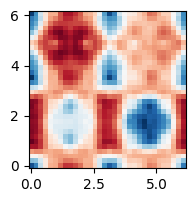

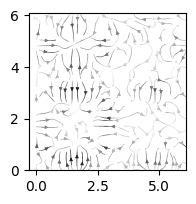

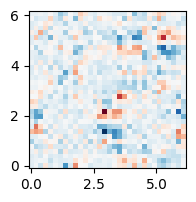

In [89]:
# %%
# =========================Run the circuit==========================
import math
nx = int(math.log2(N))
ny = int(math.log2(N))
# dt = math.pi / 1 # time step
dt = 10
#dt = 2
tmp = evolve(nx, ny, dt, initial_state)

tmp = tmp.reshape(2, N, N)
psi1 = tmp[0, :, :]
psi2 = tmp[1, :, :]

rho, ux, uy, vor = compute_fluid_quantities(psi1, psi2, N)

x = np.linspace(0, 2*pi, N, endpoint=False)
y = np.linspace(0, 2*pi, N, endpoint=False)
X, Y = np.meshgrid(x, y)


fig_width = 8/2.54
fig_height = 8/2.54
fig = plt.figure(figsize=(fig_width, fig_height))

ax_width = 4/2.54 / fig_width
ax_height = 4/2.54 / fig_height
ax = fig.add_axes([0, 0, ax_width, ax_height])
# conda qiskit
ax.set_box_aspect(1/1)

ax.pcolormesh(X, Y, rho, cmap='RdBu', shading='auto')

fig2 = plt.figure(figsize=(fig_width, fig_height))
ax2 = fig2.add_axes([0, 0, ax_width, ax_height])
ax2.set_box_aspect(1/1)

# 绘制动量方向图（矢量场）
speed = np.sqrt(ux**2 + uy**2)
streamplot_norm = mpl.colors.Normalize(vmin=0, vmax=speed.max())
streamplot_cmap = "binary"

strm = ax2.streamplot(X, Y, ux, uy,
                      density=1,
                      arrowsize=0.5,
                      color=speed,
                      norm=streamplot_norm,
                      cmap=streamplot_cmap,
                      linewidth=0.5)

fig3 = plt.figure(figsize=(fig_width, fig_height))
ax3 = fig3.add_axes([0, 0, ax_width, ax_height])
ax3.set_box_aspect(1/1)

ax3.pcolormesh(X, Y, vor, cmap='RdBu', shading='auto')




# gif

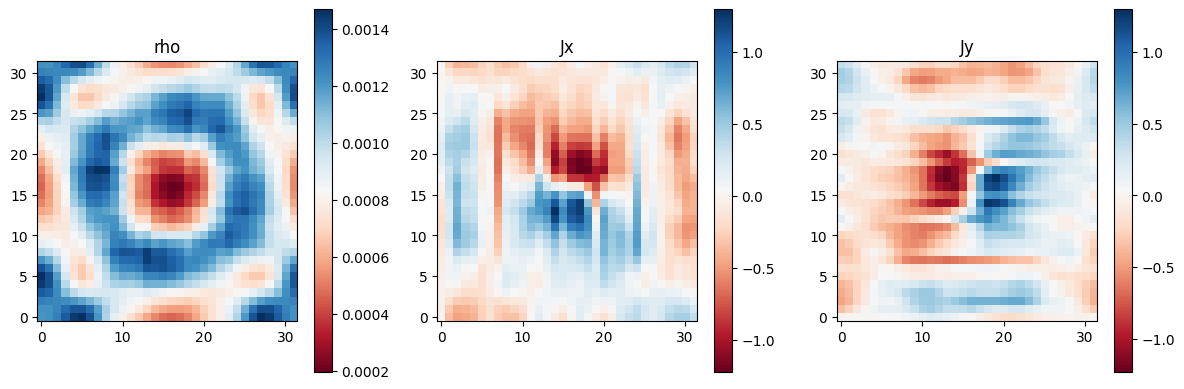

In [20]:
# --- (Optional) Visualize with matplotlib ---
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 4))
for i, (label, data) in enumerate(zip(['rho', 'Jx', 'Jy'], [rho, ux, uy])):
    plt.subplot(1, 3, i+1)
    plt.imshow(data, origin='lower', cmap='RdBu')
    plt.title(label)
    plt.colorbar()
plt.tight_layout()
plt.show()